# Ablation: Pruned Classes ± Multi-Axis Training (Run 8a / 8b)

Thin orchestration notebook for Databricks with **diagnostic analysis cells**.

## Ablation Design

Two independent interventions are tested in isolation:

| Run | `ENABLE_MULTI_AXIS` | Classes | Training data | Question answered |
|-----|---------------------|---------|---------------|-------------------|
| **8a** | `False` (default) | ~671 (pruned) | ~1,016 coronal | Does removing 657 zero-pixel classes help? |
| **8b** | `True` | ~671 (pruned) | ~2,000–2,600 (coronal + axial + sagittal) | Does adding multi-axis data on top of pruning help? |

Run 8a first. If pruning alone improves over Run 5 (68.8% mIoU), the softmax
dilution hypothesis is confirmed. Then Run 8b tells us whether multi-axis data
adds further improvement or causes regression (a concrete risk, given the TTA
result: 6-variant TTA regressed 68.4% → 44.4% because the model has zero
rotational equivariance).

## Diagnostic Cells

Beyond standard eval (Cell 7), this notebook includes:
- **Cell 8:** Per-class analysis — IoU histogram, zero-IoU class count,
  class size vs IoU scatter plot
- **Cell 9:** Cross-axis evaluation — evaluates the trained model on sampled
  sagittal and axial slices to test whether it can handle non-coronal views

## Config (same as Run 5 except class pruning)
- DINOv2-Large + UperNet, last 4 blocks unfrozen
- Differential LR: backbone 1e-5, head 1e-4
- Baseline augmentation: flip + rot15° + jitter (no rot90/elastic/blur)
- Standard CE loss
- Batch 2 × 2 grad accum = effective batch 4

In [0]:
# Cell 0 — Install project wheel from DBFS

%pip install /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
dbutils.library.restartPython()

Processing /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.5.2
    Not uninstalling accelerate at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-82a4730a-b1d2-4e8f-85bb-4f361250af86
    Can't uninstall 'accelerate'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Cell 1 — Configuration
#
# ============================================================
# ABLATION TOGGLE — the only setting you need to change
# between Run 8a (False) and Run 8b (True).
# ============================================================
ENABLE_MULTI_AXIS = False  # False = Run 8a (pruned only), True = Run 8b (pruned + multi-axis)
# ============================================================

import os
import mlflow

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"

EXPERIMENT_NAME = "/Users/noel.nosse@grainger.com/histology-brain-segmentation"
try:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
except Exception:
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
mlflow.set_experiment(experiment_id=experiment_id)
print(f"MLflow experiment: {EXPERIMENT_NAME} (ID: {experiment_id})")

# ---------- Databricks paths ----------
WORKSPACE_BASE = "/Workspace/Users/noel.nosse@grainger.com/visual-model-ft/histology"
ONTOLOGY_PATH = f"{WORKSPACE_BASE}/ontology/structure_graph_1.json"
ANNOTATION_10_PATH = f"{WORKSPACE_BASE}/ccfv3/annotation_10.nrrd"
NISSL_10_PATH = "/dbfs/FileStore/allen_brain_data/ccfv3/ara_nissl_10.nrrd"

# ---------- JFrog / HuggingFace model ----------
HF_ENDPOINT = os.environ.get(
    "HF_ENDPOINT",
    "https://graingerreadonly.jfrog.io/artifactory/api/huggingfaceml/huggingfaceml-remote",
)
MODEL_REPO_ID = "facebook/dinov2-large"
MODEL_CACHE_DIR = "/tmp/dinov2-large"

# ---------- Training hyperparameters (same as Run 5) ----------
BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
NUM_UNFROZEN_BLOCKS = 4
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 2
CROP_SIZE = 518
NUM_EPOCHS = 100
SPLIT_STRATEGY = "interleaved"

# ---------- Ablation-dependent config ----------
ABLATION_TAG = "multiaxis" if ENABLE_MULTI_AXIS else "coronal-only"
OUTPUT_DIR = f"/tmp/checkpoints/pruned-{ABLATION_TAG}"
FINAL_MODEL_DIR = f"/dbfs/FileStore/allen_brain_data/models/pruned-{ABLATION_TAG}"

HYPERPARAMS = {
    "mapping_type": "full_pruned",
    "crop_size": CROP_SIZE,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "num_unfrozen_blocks": NUM_UNFROZEN_BLOCKS,
    "num_epochs": NUM_EPOCHS,
    "freeze_backbone": False,
    "gradient_checkpointing": "backbone_only_non_reentrant",
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "split_strategy": SPLIT_STRATEGY,
    "model": MODEL_REPO_ID,
    "dataset": "CCFv3 ara_nissl_10",
    "augmentation": "baseline: flip_50pct, rot15_always, jitter_always",
    "class_pruning": True,
    "multi_axis_training": ENABLE_MULTI_AXIS,
    "ablation_tag": ABLATION_TAG,
}

print(f"{'='*65}")
print(f"ABLATION CONFIG: {ABLATION_TAG.upper()}")
print(f"{'='*65}")
print(f"Multi-axis training: {ENABLE_MULTI_AXIS}")
print(f"Class pruning:      True (remove zero-pixel classes)")
print(f"Augmentation:       baseline (flip + rot15\u00b0 + jitter)")
print(f"Batch size:         {BATCH_SIZE} (x{GRADIENT_ACCUMULATION_STEPS} = effective {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS})")
print(f"Backbone LR:        {BACKBONE_LR}")
print(f"Head LR:            {HEAD_LR}")
print(f"Unfrozen blocks:    last {NUM_UNFROZEN_BLOCKS} (blocks {24 - NUM_UNFROZEN_BLOCKS}-23)")
print(f"Epochs:             {NUM_EPOCHS}")
print(f"Output dir:         {FINAL_MODEL_DIR}")

MLflow experiment: /Users/noel.nosse@grainger.com/histology-brain-segmentation (ID: 1345391216675532)
ABLATION CONFIG: CORONAL-ONLY
Multi-axis training: False
Class pruning:      True (remove zero-pixel classes)
Augmentation:       baseline (flip + rot15° + jitter)
Batch size:         2 (x2 = effective 4)
Backbone LR:        1e-05
Head LR:            0.0001
Unfrozen blocks:    last 4 (blocks 20-23)
Epochs:             100
Output dir:         /dbfs/FileStore/allen_brain_data/models/pruned-coronal-only


In [0]:
# Cell 2 — Download model weights from JFrog Artifactory mirror

import time
from huggingface_hub import snapshot_download

print(f"Downloading {MODEL_REPO_ID} from Artifactory...")
for attempt in range(1, 4):
    try:
        model_path = snapshot_download(
            repo_id=MODEL_REPO_ID,
            endpoint=HF_ENDPOINT,
            etag_timeout=86400,
            cache_dir=MODEL_CACHE_DIR,
        )
        break
    except Exception as e:
        if attempt < 3:
            wait = 2 ** attempt
            print(f"  Attempt {attempt} failed ({e.__class__.__name__}), retrying in {wait}s...")
            time.sleep(wait)
        else:
            raise

print(f"Model downloaded to: {model_path}")

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Model downloaded to: /tmp/dinov2-large/models--facebook--dinov2-large/snapshots/a18992645e496e6d21ea90829a6652ed6f75ec47


In [0]:
# Cell 3 — Build pruned mapping + datasets + log training composition
#
# 1. Build full mapping (1,328 classes)
# 2. Scan coronal training slices for present class IDs
# 3. Build pruned mapping (present classes only, contiguous IDs)
# 4. Create training dataset (coronal-only or multi-axis, per config)
# 5. Log exact training data composition to MLflow

import numpy as np
from histological_image_analysis.ontology import OntologyMapper
from histological_image_analysis.ccfv3_slicer import CCFv3Slicer
from histological_image_analysis.dataset import BrainSegmentationDataset

# 1. Load ontology + full mapping
mapper = OntologyMapper(ONTOLOGY_PATH)
full_mapping = mapper.build_full_mapping()
full_num_labels = mapper.get_num_labels(full_mapping)
print(f"Full mapping: {full_num_labels} classes")

# 2. Load volumes
slicer = CCFv3Slicer(
    image_path=NISSL_10_PATH,
    annotation_path=ANNOTATION_10_PATH,
    ontology_mapper=mapper,
)
slicer.load_volumes()
print(f"Volume shape: {slicer.image_volume.shape}")

# 3. Scan coronal training slices for present classes
print("\nScanning coronal training slices for present classes...")
present_class_ids = set()
n_scanned = 0
for img, class_mask in slicer.iter_slices(
    "train", full_mapping, split_strategy=SPLIT_STRATEGY,
):
    present_class_ids.update(np.unique(class_mask).tolist())
    n_scanned += 1

present_nonbg = present_class_ids - {0}
absent = full_num_labels - 1 - len(present_nonbg)
print(f"Scanned {n_scanned} coronal training slices")
print(f"Present classes (excl. background): {len(present_nonbg)}")
print(f"Absent classes (zero pixels): {absent}")

# 4. Build pruned mapping
mapping = mapper.build_present_mapping(full_mapping, present_class_ids)
NUM_LABELS = mapper.get_num_labels(mapping)
class_names = mapper.get_class_names(mapping)
print(f"\nPruned mapping: {NUM_LABELS} classes (was {full_num_labels})")

# 5. Log training data composition per axis
splits = slicer.get_split_indices(
    train_frac=0.8, val_frac=0.1, split_strategy=SPLIT_STRATEGY,
)
n_coronal_train = len(splits["train"])
n_axial_valid = len(slicer._get_valid_indices(axis=1))
n_sagittal_valid = len(slicer._get_valid_indices(axis=2))

print(f"\n--- Training data composition ---")
print(f"Coronal train slices:  {n_coronal_train}")
print(f"Axial valid slices:    {n_axial_valid} {'(INCLUDED)' if ENABLE_MULTI_AXIS else '(not used)'}")
print(f"Sagittal valid slices: {n_sagittal_valid} {'(INCLUDED)' if ENABLE_MULTI_AXIS else '(not used)'}")
if ENABLE_MULTI_AXIS:
    total_train = n_coronal_train + n_axial_valid + n_sagittal_valid
    print(f"Total training slices: {total_train} ({total_train / n_coronal_train:.1f}x coronal)")

HYPERPARAMS["num_labels"] = NUM_LABELS
HYPERPARAMS["present_classes"] = len(present_nonbg)
HYPERPARAMS["absent_classes"] = absent
HYPERPARAMS["n_coronal_train"] = n_coronal_train
HYPERPARAMS["n_axial_valid"] = n_axial_valid
HYPERPARAMS["n_sagittal_valid"] = n_sagittal_valid

# 6. Create datasets
train_ds = BrainSegmentationDataset(
    slicer=slicer, split="train", mapping=mapping,
    crop_size=CROP_SIZE, augment=True, split_strategy=SPLIT_STRATEGY,
    augmentation_preset="baseline",
    multi_axis=ENABLE_MULTI_AXIS,
)
val_ds = BrainSegmentationDataset(
    slicer=slicer, split="val", mapping=mapping,
    crop_size=CROP_SIZE, augment=False, split_strategy=SPLIT_STRATEGY,
)
HYPERPARAMS["train_samples"] = len(train_ds)
HYPERPARAMS["val_samples"] = len(val_ds)

print(f"\nTrain samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)} (coronal only)")

# Sanity check
sample = train_ds[0]
print(f"\npixel_values: {sample['pixel_values'].shape}, labels: {sample['labels'].shape}")
assert sample['labels'].max().item() < NUM_LABELS, "Class ID exceeds pruned NUM_LABELS!"
print(f"Max class ID in sample: {sample['labels'].max().item()} (< {NUM_LABELS}) OK")

Full mapping: 1328 classes
Volume shape: (1320, 800, 1140)

Scanning coronal training slices for present classes...
Scanned 1016 coronal training slices
Present classes (excl. background): 672
Absent classes (zero pixels): 655

Pruned mapping: 673 classes (was 1328)

--- Training data composition ---
Coronal train slices:  1016
Axial valid slices:    677 (not used)
Sagittal valid slices: 956 (not used)

Train samples: 1016
Val samples:   127 (coronal only)

pixel_values: torch.Size([3, 518, 518]), labels: torch.Size([518, 518])
Max class ID in sample: 520 (< 673) OK


In [0]:
# Cell 4 — Create model with partially unfrozen backbone

import torch
from histological_image_analysis.training import create_model

model = create_model(
    num_labels=NUM_LABELS,
    freeze_backbone=False,
    pretrained_backbone_path=model_path,
)

first_frozen_block = 24 - NUM_UNFROZEN_BLOCKS

for param in model.backbone.embeddings.parameters():
    param.requires_grad = False
for i in range(first_frozen_block):
    for param in model.backbone.encoder.layer[i].parameters():
        param.requires_grad = False

model.backbone.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False}
)
print("Gradient checkpointing: ENABLED (backbone only, use_reentrant=False)")

backbone_frozen = sum(p.numel() for p in model.backbone.parameters() if not p.requires_grad)
backbone_trainable = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
head_trainable = sum(
    p.numel() for n, p in model.named_parameters()
    if p.requires_grad and "backbone" not in n
)
total = sum(p.numel() for p in model.parameters())

print(f"Backbone frozen:    {backbone_frozen:>12,} params")
print(f"Backbone trainable: {backbone_trainable:>12,} params (blocks {first_frozen_block}-23 + layernorm)")
print(f"Head trainable:     {head_trainable:>12,} params")
print(f"Total trainable:    {backbone_trainable + head_trainable:>12,} / {total:,} ({(backbone_trainable + head_trainable) / total * 100:.1f}%)")
print(f"\nNote: Head is smaller than Run 5 ({NUM_LABELS} vs 1,328 output classes)")

# Sanity check forward pass
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, CROP_SIZE, CROP_SIZE)
    if torch.cuda.is_available():
        model = model.cuda()
        dummy = dummy.cuda()
    out = model(pixel_values=dummy)
    print(f"\nLogits shape: {out.logits.shape}")
    logits_mb = out.logits.element_size() * out.logits.nelement() / 1e6
    print(f"Logits memory: {logits_mb:.1f} MB (was {1425.3:.1f} MB with 1,328 classes)")
    assert out.logits.shape == (1, NUM_LABELS, CROP_SIZE, CROP_SIZE)

del out, dummy
torch.cuda.empty_cache()
model = model.cpu()
torch.cuda.empty_cache()

import subprocess
print("\nGPU memory after cleanup:")
print(subprocess.check_output(["nvidia-smi", "--query-gpu=memory.used,memory.free,memory.total",
                                "--format=csv,noheader,nounits"]).decode().strip(), "MiB (used, free, total)")
print("Forward pass OK")

2026-03-15 18:20:46.635597: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773598846.651333   14738 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773598846.656224   14738 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773598846.669552   14738 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773598846.669568   14738 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773598846.669571   14738 computation_placer.cc:177] computation placer alr

[2026-03-15 18:20:49,169] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Gradient checkpointing: ENABLED (backbone only, use_reentrant=False)
Backbone frozen:     253,973,504 params
Backbone trainable:   50,395,136 params (blocks 20-23 + layernorm)
Head trainable:       37,231,170 params
Total trainable:      87,626,306 / 341,599,810 (25.7%)

Note: Head is smaller than Run 5 (673 vs 1,328 output classes)

Logits shape: torch.Size([1, 673, 518, 518])
Logits memory: 722.3 MB (was 1425.3 MB with 1,328 classes)

GPU memory after cleanup:
10218, 35377, 46068 MiB (used, free, total)
Forward pass OK


In [0]:
# Cell 5 — Train with differential learning rate

import torch
from datetime import datetime
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from histological_image_analysis.training import (
    get_training_args,
    make_compute_metrics,
    preprocess_logits_for_metrics,
)
from transformers import Trainer

run_name = f"pruned-{ABLATION_TAG}-{NUM_LABELS}class-{datetime.now().strftime('%Y%m%d-%H%M')}"
mlflow.start_run(run_name=run_name)
mlflow.log_params(HYPERPARAMS)

training_args = get_training_args(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=HEAD_LR,
    fp16=torch.cuda.is_available(),
    report_to="mlflow",
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    ddp_find_unused_parameters=True,
    dataloader_drop_last=True,  # REQUIRED: odd sample counts cause batch_size=1
    # at epoch end → UperNet PSP BatchNorm crashes on [1,512,1,1].
    # Multi-axis gives 2,649 samples; coronal gives 1,016 (even, but safe to always set).
)

backbone_params = [
    p for n, p in model.named_parameters()
    if p.requires_grad and "backbone" in n
]
head_params = [
    p for n, p in model.named_parameters()
    if p.requires_grad and "backbone" not in n
]

optimizer = AdamW(
    [
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=HYPERPARAMS["weight_decay"],
)

num_training_steps = (len(train_ds) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)) * NUM_EPOCHS
num_warmup_steps = int(num_training_steps * HYPERPARAMS["warmup_ratio"])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print(f"Run: {run_name}")
print(f"Optimizer: AdamW, backbone lr={BACKBONE_LR}, head lr={HEAD_LR}")
print(f"Batch: {BATCH_SIZE} x {GRADIENT_ACCUMULATION_STEPS} = effective {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Training samples: {len(train_ds)} (drop_last=True) | Steps/epoch: {len(train_ds) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)}")
print(f"Total steps: {num_training_steps} | Warmup: {num_warmup_steps}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=make_compute_metrics(NUM_LABELS),
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    optimizers=(optimizer, scheduler),
)

trainer.train()

2026/03/15 18:20:57 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/15 18:20:57 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Run: pruned-coronal-only-673class-20260315-1820
Optimizer: AdamW, backbone lr=1e-05, head lr=0.0001
Batch: 2 x 2 = effective 4
Training samples: 1016 (drop_last=True) | Steps/epoch: 254
Total steps: 25400 | Warmup: 2540


Trainer is attempting to log a value of "{0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4', 5: 'LABEL_5', 6: 'LABEL_6', 7: 'LABEL_7', 8: 'LABEL_8', 9: 'LABEL_9', 10: 'LABEL_10', 11: 'LABEL_11', 12: 'LABEL_12', 13: 'LABEL_13', 14: 'LABEL_14', 15: 'LABEL_15', 16: 'LABEL_16', 17: 'LABEL_17', 18: 'LABEL_18', 19: 'LABEL_19', 20: 'LABEL_20', 21: 'LABEL_21', 22: 'LABEL_22', 23: 'LABEL_23', 24: 'LABEL_24', 25: 'LABEL_25', 26: 'LABEL_26', 27: 'LABEL_27', 28: 'LABEL_28', 29: 'LABEL_29', 30: 'LABEL_30', 31: 'LABEL_31', 32: 'LABEL_32', 33: 'LABEL_33', 34: 'LABEL_34', 35: 'LABEL_35', 36: 'LABEL_36', 37: 'LABEL_37', 38: 'LABEL_38', 39: 'LABEL_39', 40: 'LABEL_40', 41: 'LABEL_41', 42: 'LABEL_42', 43: 'LABEL_43', 44: 'LABEL_44', 45: 'LABEL_45', 46: 'LABEL_46', 47: 'LABEL_47', 48: 'LABEL_48', 49: 'LABEL_49', 50: 'LABEL_50', 51: 'LABEL_51', 52: 'LABEL_52', 53: 'LABEL_53', 54: 'LABEL_54', 55: 'LABEL_55', 56: 'LABEL_56', 57: 'LABEL_57', 58: 'LABEL_58', 59: 'LABEL_59', 60: 'LABEL_60', 61

Epoch,Training Loss,Validation Loss,Mean Iou,Overall Accuracy,Iou Class 0,Iou Class 1,Iou Class 2,Iou Class 3,Iou Class 4,Iou Class 5,Iou Class 6,Iou Class 7,Iou Class 8,Iou Class 9,Iou Class 10,Iou Class 11,Iou Class 12,Iou Class 13,Iou Class 14,Iou Class 15,Iou Class 16,Iou Class 17,Iou Class 18,Iou Class 19,Iou Class 20,Iou Class 21,Iou Class 22,Iou Class 23,Iou Class 24,Iou Class 25,Iou Class 26,Iou Class 27,Iou Class 28,Iou Class 29,Iou Class 30,Iou Class 31,Iou Class 32,Iou Class 33,Iou Class 34,Iou Class 35,Iou Class 36,Iou Class 37,Iou Class 38,Iou Class 39,Iou Class 40,Iou Class 41,Iou Class 42,Iou Class 43,Iou Class 44,Iou Class 45,Iou Class 46,Iou Class 47,Iou Class 48,Iou Class 49,Iou Class 50,Iou Class 51,Iou Class 52,Iou Class 53,Iou Class 54,Iou Class 55,Iou Class 56,Iou Class 57,Iou Class 58,Iou Class 59,Iou Class 60,Iou Class 61,Iou Class 62,Iou Class 63,Iou Class 64,Iou Class 65,Iou Class 66,Iou Class 67,Iou Class 68,Iou Class 69,Iou Class 70,Iou Class 71,Iou Class 72,Iou Class 73,Iou Class 74,Iou Class 75,Iou Class 76,Iou Class 77,Iou Class 78,Iou Class 79,Iou Class 80,Iou Class 81,Iou Class 82,Iou Class 83,Iou Class 84,Iou Class 85,Iou Class 86,Iou Class 87,Iou Class 88,Iou Class 89,Iou Class 90,Iou Class 91,Iou Class 92,Iou Class 93,Iou Class 94,Iou Class 95,Iou Class 96,Iou Class 97,Iou Class 98,Iou Class 99,Iou Class 100,Iou Class 101,Iou Class 102,Iou Class 103,Iou Class 104,Iou Class 105,Iou Class 106,Iou Class 107,Iou Class 108,Iou Class 109,Iou Class 110,Iou Class 111,Iou Class 112,Iou Class 113,Iou Class 114,Iou Class 115,Iou Class 116,Iou Class 117,Iou Class 118,Iou Class 119,Iou Class 120,Iou Class 121,Iou Class 122,Iou Class 123,Iou Class 124,Iou Class 125,Iou Class 126,Iou Class 127,Iou Class 128,Iou Class 129,Iou Class 130,Iou Class 131,Iou Class 132,Iou Class 133,Iou Class 134,Iou Class 135,Iou Class 136,Iou Class 137,Iou Class 138,Iou Class 139,Iou Class 140,Iou Class 141,Iou Class 142,Iou Class 143,Iou Class 144,Iou Class 145,Iou Class 146,Iou Class 147,Iou Class 148,Iou Class 149,Iou Class 150,Iou Class 151,Iou Class 152,Iou Class 153,Iou Class 154,Iou Class 155,Iou Class 156,Iou Class 157,Iou Class 158,Iou Class 159,Iou Class 160,Iou Class 161,Iou Class 162,Iou Class 163,Iou Class 164,Iou Class 165,Iou Class 166,Iou Class 167,Iou Class 168,Iou Class 169,Iou Class 170,Iou Class 171,Iou Class 172,Iou Class 173,Iou Class 174,Iou Class 175,Iou Class 176,Iou Class 177,Iou Class 178,Iou Class 179,Iou Class 180,Iou Class 181,Iou Class 182,Iou Class 183,Iou Class 184,Iou Class 185,Iou Class 186,Iou Class 187,Iou Class 188,Iou Class 189,Iou Class 190,Iou Class 191,Iou Class 192,Iou Class 193,Iou Class 194,Iou Class 195,Iou Class 196,Iou Class 197,Iou Class 198,Iou Class 199,Iou Class 200,Iou Class 201,Iou Class 202,Iou Class 203,Iou Class 204,Iou Class 205,Iou Class 206,Iou Class 207,Iou Class 208,Iou Class 209,Iou Class 210,Iou Class 211,Iou Class 212,Iou Class 213,Iou Class 214,Iou Class 215,Iou Class 216,Iou Class 217,Iou Class 218,Iou Class 219,Iou Class 220,Iou Class 221,Iou Class 222,Iou Class 223,Iou Class 224,Iou Class 225,Iou Class 226,Iou Class 227,Iou Class 228,Iou Class 229,Iou Class 230,Iou Class 231,Iou Class 232,Iou Class 233,Iou Class 234,Iou Class 235,Iou Class 236,Iou Class 237,Iou Class 238,Iou Class 239,Iou Class 240,Iou Class 241,Iou Class 242,Iou Class 243,Iou Class 244,Iou Class 245,Iou Class 246,Iou Class 247,Iou Class 248,Iou Class 249,Iou Class 250,Iou Class 251,Iou Class 252,Iou Class 253,Iou Class 254,Iou Class 255,Iou Class 256,Iou Class 257,Iou Class 258,Iou Class 259,Iou Class 260,Iou Class 261,Iou Class 262,Iou Class 263,Iou Class 264,Iou Class 265,Iou Class 266,Iou Class 267,Iou Class 268,Iou Class 269,Iou Class 270,Iou Class 271,Iou Class 272,Iou Class 273,Iou Class 274,Iou Class 275,Iou Class 276,Iou Class 277,Iou Class 278,Iou Class 279,Iou Class 280,Iou Class 281,Iou Class 282,Iou Class 283,Iou Class 284,Iou Class 285,Iou Class 286,Iou Class 287,Iou Class 288,Io

TrainOutput(global_step=25400, training_loss=0.7083654451839567, metrics={'train_runtime': 22278.8432, 'train_samples_per_second': 4.56, 'train_steps_per_second': 1.14, 'total_flos': 1.6762676174198407e+20, 'train_loss': 0.7083654451839567, 'epoch': 100.0})

In [0]:
# Cell 6 — Primary evaluation (coronal val set)
#
# Val set is coronal-only, identical to all previous runs.

import numpy as np

eval_results = trainer.evaluate()
print("Evaluation results:")
for k, v in sorted(eval_results.items()):
    if isinstance(v, float) and not k.startswith("eval_iou_class_"):
        print(f"  {k}: {v:.4f}")

mlflow.log_metrics({
    "final_mean_iou": eval_results.get("eval_mean_iou", 0.0),
    "final_overall_accuracy": eval_results.get("eval_overall_accuracy", 0.0),
})

# Collect per-class IoU
class_ious = {}
for cls in range(NUM_LABELS):
    iou_key = f"eval_iou_class_{cls}"
    iou = eval_results.get(iou_key, float('nan'))
    if not np.isnan(iou):
        class_ious[cls] = iou

sorted_ious = sorted(class_ious.items(), key=lambda x: x[1], reverse=True)
print(f"\nTop 10 classes by IoU:")
for cls, iou in sorted_ious[:10]:
    name = class_names[cls] if cls < len(class_names) else f"class_{cls}"
    print(f"  {cls:4d} ({name:40s}): {iou:.4f}")

print(f"\nBottom 10 classes by IoU (non-zero):")
nonzero_ious = [(c, i) for c, i in sorted_ious if i > 0]
for cls, iou in nonzero_ious[-10:]:
    name = class_names[cls] if cls < len(class_names) else f"class_{cls}"
    print(f"  {cls:4d} ({name:40s}): {iou:.4f}")

current_miou = eval_results.get('eval_mean_iou', 0.0)
current_acc = eval_results.get('eval_overall_accuracy', 0.0)
n_valid = len(class_ious)

print(f"\nClasses with valid IoU: {n_valid} / {NUM_LABELS}")

# --- Comparison with Run 5 ---
print(f"\n{'='*65}")
print(f"COMPARISON WITH RUN 5 (unfrozen baseline)")
print(f"{'='*65}")
print(f"")
print(f"                    Run 5              This run ({ABLATION_TAG})")
print(f"  Mapping:          1,328 classes       {NUM_LABELS} classes (pruned)")
print(f"  Valid classes:    503 / 1,328         {n_valid} / {NUM_LABELS}")
print(f"  mIoU:             68.8%               {current_miou:.1%}")
print(f"  Accuracy:         92.5%               {current_acc:.1%}")
print(f"  Training data:    1,016 coronal       {len(train_ds)} slices")
print(f"")
print(f"  NOTE: mIoU is NOT directly comparable (different class sets).")
print(f"  Run 5 averaged over 503 classes including many low-IoU ones.")
print(f"  This run averages over {n_valid} classes (zero-pixel classes removed).")
print(f"  Overall accuracy IS comparable (same val pixels, same annotations).")
print(f"  Accuracy delta vs Run 5: {current_acc - 0.9248:+.1%}")

Evaluation results:
  epoch: 100.0000
  eval_loss: 0.3681
  eval_mean_iou: 0.6903
  eval_overall_accuracy: 0.9240
  eval_runtime: 54.9338
  eval_samples_per_second: 2.3120
  eval_steps_per_second: 1.1650

Top 10 classes by IoU:
   335 (Caudoputamen                            ): 0.9730
   244 (Main olfactory bulb                     ): 0.9669
     0 (Background                              ): 0.9647
   492 (Nodulus (X)                             ): 0.9541
    83 (Anterior olfactory nucleus              ): 0.9371
   505 (Lobule III                              ): 0.9354
   484 (Uvula (IX)                              ): 0.9353
   198 (Field CA1                               ): 0.9344
   566 (Lobules IV-V                            ): 0.9319
   470 (Declive (VI)                            ): 0.9311

Bottom 10 classes by IoU (non-zero):
   459 (trochlear nerve                         ): 0.0926
   618 (Rostrolateral area, layer 6a            ): 0.0890
   229 (Midbrain trigeminal nucleus   

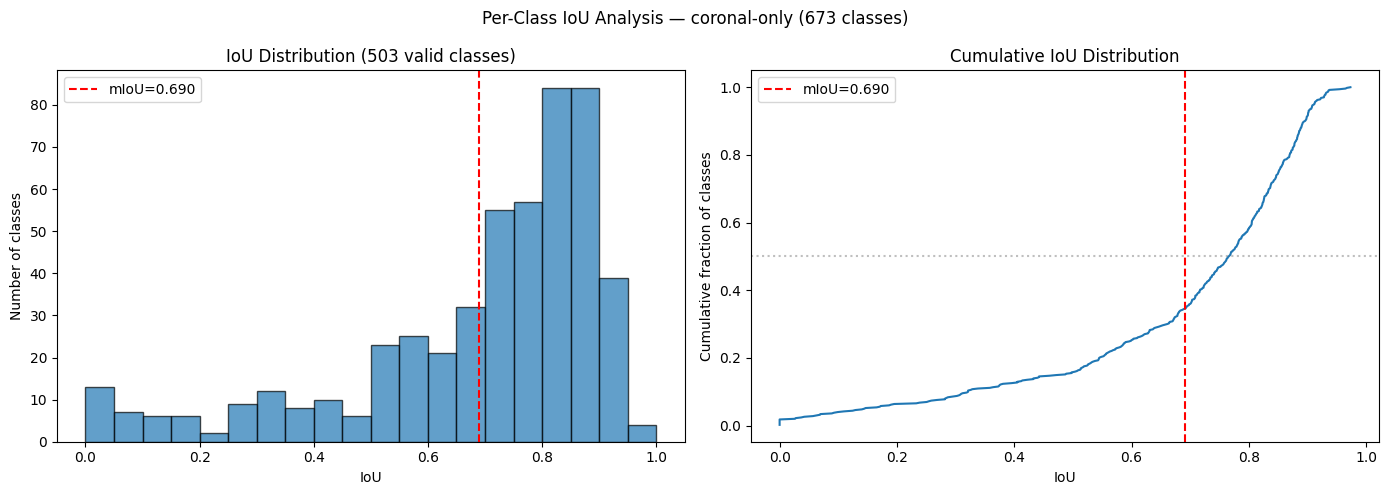


--- IoU Bracket Analysis ---
  Zero IoU (0.0):       9 classes (present in val but never correctly predicted)
  Low IoU (0-0.1):     11 classes
  Medium IoU (0.1-0.5):   59 classes
  High IoU (>=0.5):   424 classes
  NaN (absent from val):  170 classes

Computing per-class pixel counts from val set...
Classes with >0 val pixels: 504


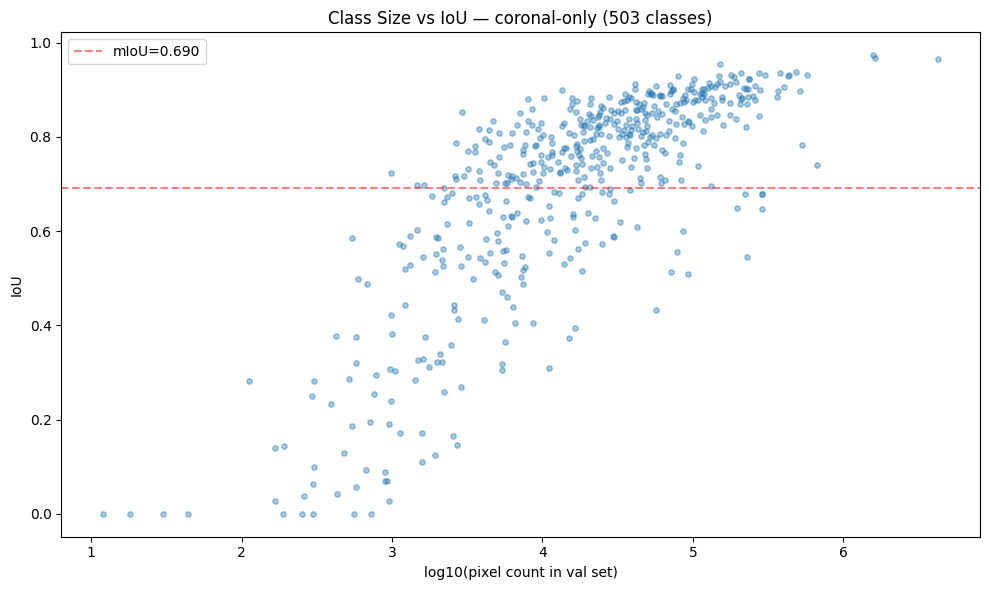


Correlation(log_pixels, IoU) = 0.794
  Moderate positive correlation: larger classes have higher IoU (expected).


In [0]:
# Cell 7 — Diagnostic: per-class analysis
#
# Three analyses beyond top-10/bottom-10:
# 1. IoU distribution histogram
# 2. Zero-IoU class breakdown
# 3. Class size (pixel count) vs IoU scatter

import matplotlib.pyplot as plt
import numpy as np

# --- 1. IoU distribution histogram ---

valid_iou_values = np.array([iou for iou in class_ious.values()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(valid_iou_values, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
axes[0].axvline(current_miou, color='red', linestyle='--', label=f'mIoU={current_miou:.3f}')
axes[0].set_xlabel('IoU')
axes[0].set_ylabel('Number of classes')
axes[0].set_title(f'IoU Distribution ({n_valid} valid classes)')
axes[0].legend()

# Cumulative distribution
sorted_vals = np.sort(valid_iou_values)
axes[1].plot(sorted_vals, np.arange(1, len(sorted_vals) + 1) / len(sorted_vals))
axes[1].axvline(current_miou, color='red', linestyle='--', label=f'mIoU={current_miou:.3f}')
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('IoU')
axes[1].set_ylabel('Cumulative fraction of classes')
axes[1].set_title('Cumulative IoU Distribution')
axes[1].legend()

plt.suptitle(f'Per-Class IoU Analysis — {ABLATION_TAG} ({NUM_LABELS} classes)')
plt.tight_layout()
plt.show()

# --- 2. Zero-IoU class analysis ---

zero_iou_classes = [cls for cls, iou in class_ious.items() if iou == 0.0]
low_iou_classes = [cls for cls, iou in class_ious.items() if 0 < iou < 0.1]
medium_iou_classes = [cls for cls, iou in class_ious.items() if 0.1 <= iou < 0.5]
high_iou_classes = [cls for cls, iou in class_ious.items() if iou >= 0.5]

print(f"\n--- IoU Bracket Analysis ---")
print(f"  Zero IoU (0.0):    {len(zero_iou_classes):4d} classes (present in val but never correctly predicted)")
print(f"  Low IoU (0-0.1):   {len(low_iou_classes):4d} classes")
print(f"  Medium IoU (0.1-0.5): {len(medium_iou_classes):4d} classes")
print(f"  High IoU (>=0.5):  {len(high_iou_classes):4d} classes")
print(f"  NaN (absent from val): {NUM_LABELS - n_valid:4d} classes")

# --- 3. Class size vs IoU scatter ---

print("\nComputing per-class pixel counts from val set...")


def compute_class_pixel_counts(val_ds, num_labels, crop_size):
    """Count total pixels per class in the center-cropped validation set."""
    counts = np.zeros(num_labels, dtype=np.int64)
    for img, mask in val_ds._slices:
        h, w = mask.shape
        # Pad if needed
        pad_h = max(0, crop_size - h)
        pad_w = max(0, crop_size - w)
        if pad_h > 0 or pad_w > 0:
            mask = np.pad(mask, ((pad_h // 2, pad_h - pad_h // 2),
                                 (pad_w // 2, pad_w - pad_w // 2)),
                          mode='constant', constant_values=0)
        # Center crop
        h, w = mask.shape
        top = (h - crop_size) // 2
        left = (w - crop_size) // 2
        mask = mask[top:top + crop_size, left:left + crop_size]
        # Count
        unique, pixel_counts = np.unique(mask, return_counts=True)
        for cls_id, cnt in zip(unique, pixel_counts):
            if cls_id < num_labels:
                counts[cls_id] += cnt
    return {i: int(counts[i]) for i in range(num_labels) if counts[i] > 0}


class_pixel_counts = compute_class_pixel_counts(val_ds, NUM_LABELS, CROP_SIZE)
print(f"Classes with >0 val pixels: {len(class_pixel_counts)}")

# Scatter: log(pixels) vs IoU
scatter_classes = [cls for cls in class_ious if cls in class_pixel_counts and class_pixel_counts[cls] > 0]
scatter_x = [np.log10(class_pixel_counts[cls]) for cls in scatter_classes]
scatter_y = [class_ious[cls] for cls in scatter_classes]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_x, scatter_y, alpha=0.4, s=15)
ax.set_xlabel('log10(pixel count in val set)')
ax.set_ylabel('IoU')
ax.set_title(f'Class Size vs IoU — {ABLATION_TAG} ({len(scatter_classes)} classes)')
ax.axhline(current_miou, color='red', linestyle='--', alpha=0.5, label=f'mIoU={current_miou:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

# Correlation
if len(scatter_x) > 2:
    corr = np.corrcoef(scatter_x, scatter_y)[0, 1]
    print(f"\nCorrelation(log_pixels, IoU) = {corr:.3f}")
    if corr > 0.3:
        print("  Moderate positive correlation: larger classes have higher IoU (expected).")
    elif corr > 0.1:
        print("  Weak positive correlation.")
    else:
        print("  No meaningful correlation: class size does not predict IoU.")

# Log diagnostic metrics
mlflow.log_metrics({
    "diag_zero_iou_classes": len(zero_iou_classes),
    "diag_low_iou_classes": len(low_iou_classes),
    "diag_high_iou_classes": len(high_iou_classes),
    "diag_size_iou_correlation": float(corr) if len(scatter_x) > 2 else 0.0,
})

In [0]:
# Cell 8 — Diagnostic: cross-axis evaluation
#
# Evaluate the trained model on sampled sagittal and axial slices.
# This answers: "can this model handle non-coronal views?"
#
# For Run 8a (coronal-only training): expect near-zero performance
#   on non-coronal axes (confirms TTA finding).
# For Run 8b (multi-axis training): non-trivial performance proves
#   the model learned those orientations during training.

import torch
import numpy as np
from tqdm.auto import tqdm

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def normalize_for_inference(image):
    """Convert uint8 grayscale (H, W) to normalized 3-channel tensor (1, 3, H, W)."""
    img_float = image.astype(np.float32) / 255.0
    img_3ch = np.stack([img_float, img_float, img_float], axis=0)
    for c in range(3):
        img_3ch[c] = (img_3ch[c] - IMAGENET_MEAN[c]) / IMAGENET_STD[c]
    return torch.from_numpy(img_3ch).unsqueeze(0)


def pad_and_center_crop(image, mask, crop_size):
    """Pad to crop_size if needed, then center crop."""
    h, w = image.shape[:2]
    pad_h = max(0, crop_size - h)
    pad_w = max(0, crop_size - w)
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image,
                       ((pad_h // 2, pad_h - pad_h // 2),
                        (pad_w // 2, pad_w - pad_w // 2)),
                       mode='constant', constant_values=0)
        mask = np.pad(mask,
                      ((pad_h // 2, pad_h - pad_h // 2),
                       (pad_w // 2, pad_w - pad_w // 2)),
                      mode='constant', constant_values=0)
    h, w = image.shape[:2]
    top = (h - crop_size) // 2
    left = (w - crop_size) // 2
    return (
        image[top:top + crop_size, left:left + crop_size],
        mask[top:top + crop_size, left:left + crop_size],
    )


def evaluate_axis(model, slicer, mapper, mapping, axis, device,
                  num_labels, crop_size=518, sample_every=10):
    """Evaluate model on sampled slices along a given axis.

    Returns dict with mean_iou, accuracy, n_samples, n_valid_classes.
    """
    axis_names = {0: "coronal", 1: "axial", 2: "sagittal"}
    valid_indices = slicer._get_valid_indices(axis=axis)
    sampled = valid_indices[::sample_every]

    all_preds = []
    all_labels = []

    model.eval()
    for idx in tqdm(sampled, desc=f"{axis_names.get(axis, str(axis))} eval"):
        img, annot = slicer.get_slice(idx, axis=axis)
        class_mask = mapper.remap_mask(annot, mapping)
        img, class_mask = pad_and_center_crop(img, class_mask, crop_size)

        pixel_values = normalize_for_inference(img).to(device)
        with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
            logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int64)

        all_preds.append(preds.ravel())
        all_labels.append(class_mask.ravel())

    preds_flat = np.concatenate(all_preds)
    labels_flat = np.concatenate(all_labels)

    accuracy = float((preds_flat == labels_flat).sum()) / len(labels_flat)

    valid_ious = []
    for cls in range(num_labels):
        label_mask = labels_flat == cls
        if label_mask.sum() == 0:
            continue
        pred_mask = preds_flat == cls
        intersection = (pred_mask & label_mask).sum()
        union = (pred_mask | label_mask).sum()
        if union > 0:
            valid_ious.append(float(intersection) / float(union))
        else:
            valid_ious.append(0.0)

    mean_iou = float(np.mean(valid_ious)) if valid_ious else 0.0

    return {
        "axis": axis,
        "axis_name": axis_names.get(axis, str(axis)),
        "mean_iou": mean_iou,
        "accuracy": accuracy,
        "n_samples": len(sampled),
        "n_valid_classes": len(valid_ious),
        "n_total_valid": len(valid_indices),
    }


# Run cross-axis evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

axis_results = {}
for axis in (0, 1, 2):
    print(f"\nEvaluating on axis {axis}...")
    result = evaluate_axis(
        model, slicer, mapper, mapping, axis, device,
        num_labels=NUM_LABELS, crop_size=CROP_SIZE, sample_every=10,
    )
    axis_results[axis] = result
    print(f"  {result['axis_name']:>9s}: mIoU={result['mean_iou']:.4f}, "
          f"acc={result['accuracy']:.4f}, "
          f"samples={result['n_samples']}/{result['n_total_valid']}")

# Summary table
print(f"\n{'='*70}")
print(f"CROSS-AXIS EVALUATION SUMMARY ({ABLATION_TAG})")
print(f"{'='*70}")
print(f"{'Axis':<12} {'Samples':>8} {'mIoU':>8} {'Accuracy':>10} {'Valid Cls':>10}")
print(f"{'-'*70}")
for axis in (0, 1, 2):
    r = axis_results[axis]
    trained_on = "TRAINED" if (axis == 0 or ENABLE_MULTI_AXIS) else "unseen"
    print(f"{r['axis_name']:<12} {r['n_samples']:>8d} {r['mean_iou']:>8.4f} "
          f"{r['accuracy']:>10.4f} {r['n_valid_classes']:>10d}  [{trained_on}]")

# Interpretation
coronal_miou = axis_results[0]['mean_iou']
axial_miou = axis_results[1]['mean_iou']
sagittal_miou = axis_results[2]['mean_iou']

print(f"\nInterpretation:")
if not ENABLE_MULTI_AXIS:
    print(f"  Training was coronal-only. Non-coronal performance is a generalization test.")
    if axial_miou < 0.1 and sagittal_miou < 0.1:
        print(f"  Result: Model cannot generalize to unseen orientations (consistent with TTA finding).")
    elif axial_miou > 0.3 or sagittal_miou > 0.3:
        print(f"  Result: Surprising cross-axis generalization! The model learned some orientation-invariant features.")
    else:
        print(f"  Result: Partial cross-axis ability. Some features transfer across orientations.")
else:
    print(f"  Training included all 3 axes.")
    print(f"  Coronal mIoU: {coronal_miou:.4f} (primary metric, comparable to Run 5)")
    print(f"  Axial mIoU:   {axial_miou:.4f}")
    print(f"  Sagittal mIoU: {sagittal_miou:.4f}")
    if axial_miou > 0.3 and sagittal_miou > 0.3:
        print(f"  Result: Model learned all orientations. Multi-axis training worked.")
    else:
        print(f"  Result: Multi-axis training had limited effect on non-coronal performance.")

# Log to MLflow
for axis in (0, 1, 2):
    r = axis_results[axis]
    mlflow.log_metrics({
        f"diag_{r['axis_name']}_miou": r['mean_iou'],
        f"diag_{r['axis_name']}_accuracy": r['accuracy'],
    })

# Move model back to CPU for save cell
model = model.cpu()
torch.cuda.empty_cache()


Evaluating on axis 0...


coronal eval:   0%|          | 0/127 [00:00<?, ?it/s]

    coronal: mIoU=0.6890, acc=0.9235, samples=127/1270

Evaluating on axis 1...


axial eval:   0%|          | 0/68 [00:00<?, ?it/s]

      axial: mIoU=0.0322, acc=0.2293, samples=68/677

Evaluating on axis 2...


sagittal eval:   0%|          | 0/96 [00:00<?, ?it/s]

   sagittal: mIoU=0.0050, acc=0.1280, samples=96/956

CROSS-AXIS EVALUATION SUMMARY (coronal-only)
Axis          Samples     mIoU   Accuracy  Valid Cls
----------------------------------------------------------------------
coronal           127   0.6890     0.9235        504  [TRAINED]
axial              68   0.0322     0.2293        379  [unseen]
sagittal           96   0.0050     0.1280        464  [unseen]

Interpretation:
  Training was coronal-only. Non-coronal performance is a generalization test.
  Result: Model cannot generalize to unseen orientations (consistent with TTA finding).


In [0]:
pr

mlflow.log_artifact(metadata_path, artifact_path="metadata")
print("Metadata logged as MLflow artifact")

# 6. Close MLflow run
mlflow.end_run()
print(f"\nMLflow run closed. Ablation: {ABLATION_TAG}")
print(f"To run the other ablation, change ENABLE_MULTI_AXIS in Cell 1 and re-run all cells.")

2026-03-16 03:54:26.373658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773633266.390224    2860 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773633266.395252    2860 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773633266.410513    2860 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773633266.410525    2860 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773633266.410527    2860 computation_placer.cc:177] computation placer alr

[2026-03-16 03:54:34,812] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


df: /root/.triton/autotune: No such file or directory
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8553150081625347>, line 18
     15 os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
     17 # 1. Set id2label/label2id
---> 18 model.config.id2label = {i: name for i, name in enumerate(class_names)}
     19 model.config.label2id = {name: i for i, name in enumerate(class_names)}
     20 print(f"Set id2label/label2id: {NUM_LABELS} classes")

NameError: name 'class_names' is not defined

In [ ]:
Model directory: /dbfs/FileStore/allen_brain_data/models/pruned-coronal-only
Contents: ['ablation_metadata.json', 'config.json', 'model.safetensors', 'preprocessor_config.json', 'training_args.bin']
Metadata loaded: coronal-only, 673 classes
MLflow experiment: /Users/noel.nosse@grainger.com/histology-brain-segmentation (ID: 1345391216675532)